
Riel A:
 [[0.49671415 0.         0.64768854]
 [1.52302986 0.         0.        ]
 [1.57921282 0.76743473 0.        ]
 [0.54256004 0.         0.        ]
 [0.24196227 0.         0.        ]
 [0.         0.         0.31424733]
 [0.         0.         1.46564877]
 [0.         0.0675282  0.        ]
 [0.         0.11092259 0.        ]
 [0.37569802 0.         0.        ]
 [0.         1.85227818 0.        ]
 [0.         0.82254491 0.        ]
 [0.2088636  0.         0.        ]
 [0.19686124 0.73846658 0.17136828]
 [0.         0.         0.        ]
 [0.         0.         1.05712223]
 [0.34361829 0.         0.32408397]
 [0.         0.         0.61167629]
 [1.03099952 0.93128012 0.        ]
 [0.         0.33126343 0.97554513]]

Riel B[0]:
 [[0.         0.         0.        ]
 [0.         0.81252582 1.35624003]
 [0.         1.0035329  0.36163603]
 [0.         0.36139561 1.53803657]
 [0.         1.56464366 0.        ]
 [0.8219025  0.08704707 0.        ]
 [0.09176078 0.         0.        ]
 [0.

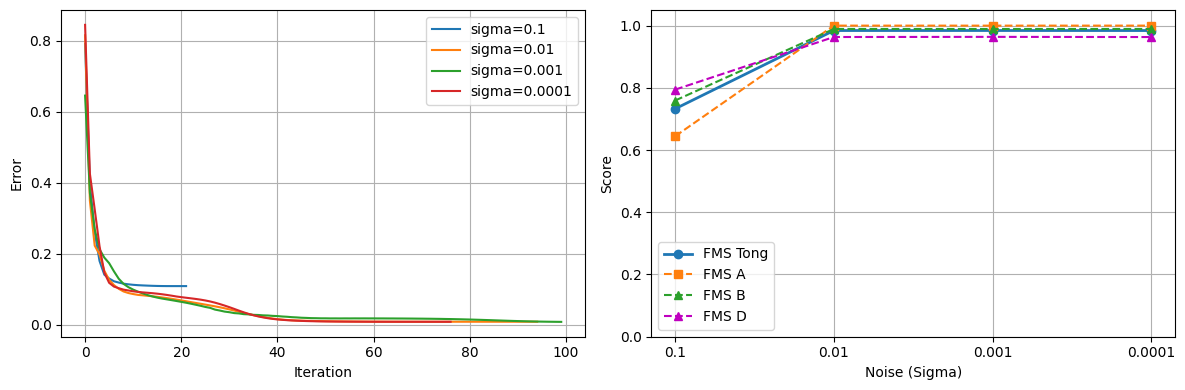

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

def fms(A_true, A_est):
    R = A_true.shape[1]

    norm_true = np.linalg.norm(A_true, axis=0, keepdims=True)
    norm_est = np.linalg.norm(A_est, axis=0, keepdims=True)
    norm_true[norm_true == 0] = 1e-12
    norm_est[norm_est == 0] = 1e-12

    A_true_norm = A_true / norm_true
    A_est_norm = A_est / norm_est

    cost_mat = 1.0 - np.abs(A_true_norm.T @ A_est_norm)

    row_id, col_id = linear_sum_assignment(cost_mat)

    fms_val = np.mean([np.abs(np.dot(A_true_norm[:,r], A_est_norm[:,c])) for r, c in zip(row_id, col_id)])

    return fms_val, col_id

def parafac2_fms(A_true, B_true_list, D_true_list, A_est, B_est_list, D_est_list):
    K = len(B_true_list)

    fms_A, perm = fms(A_true, A_est)

    A_est_perm = A_est[:, perm]
    B_est_perm = [B[:, perm] for B in B_est_list]
    D_est_perm = [D[perm] for D in D_est_list]

    fms_B_list = []
    for k in range(K):
        fms_Bk, _ = fms(B_true_list[k], B_est_perm[k])
        fms_B_list.append(fms_Bk)

    fms_B = np.mean(fms_B_list)

    D_true_mat = np.array(D_true_list)
    D_est_mat = np.array(D_est_perm)
    fms_D, _ = fms(D_true_mat, D_est_mat)

    fms_overall = (fms_A + fms_B + fms_D) / 3.0
    return fms_overall, fms_A, fms_B, fms_D


def update_rho(A, B_list, D_vecs):

    K = len(B_list)
    R = A.shape[1]

    # rho_A = sum_k ||B_k * D_k||_F^2 / R
    rho_A = sum(np.linalg.norm(B_list[k] * D_vecs[k], 'fro')**2 for k in range(K)) / R

    # rho_B_k = ||A * D_k||_F^2 / R
    rho_B = [np.linalg.norm(A * D_vecs[k], 'fro')**2 / R for k in range(K)]

    # rho_D_k = Tr((A^T A) * (B_k^T B_k)) / R
    ATA = A.T @ A
    rho_D = [np.trace(ATA * (B_list[k].T @ B_list[k])) / R for k in range(K)]

    return rho_A, rho_B, rho_D



def update_B_mode(X_list, A, D_vecs, B_list, ZB_list, YB_list, muZB_list, muDeltaB_list, P_list, Delta_B, rho_B,prox_gB):

    K = len(X_list)
    R = A.shape[1]

    for k in range(K):
        D_k = np.diag(D_vecs[k])
        rhs = X_list[k].T @ A @ D_k + 0.5 * rho_B[k] * (ZB_list[k] - muZB_list[k] + YB_list[k] - muDeltaB_list[k])
        lhs = D_k @ A.T @ A @ D_k + rho_B[k] * np.eye(R)

        # B_k = RHS * inv(LHS)
        B_list[k] = np.linalg.solve(lhs.T, rhs.T).T



    for k in range(K):
        ZB_list[k] = prox_gB(B_list[k] + muZB_list[k], scale=1.0 / rho_B[k])


    for k in range(K):
        M = (B_list[k] + muDeltaB_list[k]) @ Delta_B.T
        U,_,Vt = np.linalg.svd(M,full_matrices=False)
        P_list[k] = U @ Vt



    sigma_rho = np.sum(rho_B)
    weighted_proj_sum = sum(
        rho_B[k] * (P_list[k].T @ (B_list[k] + muDeltaB_list[k]))
        for k in range(K)                    
    )

    Delta_B = weighted_proj_sum / sigma_rho

    for k in range(K):
        YB_list[k] = P_list[k] @ Delta_B



    for k in range(K):

        muZB_list[k] += B_list[k] - ZB_list[k]
        muDeltaB_list[k] += B_list[k] - YB_list[k]

    return B_list, ZB_list, YB_list, muZB_list, muDeltaB_list, P_list,Delta_B



def update_A_mode(X_list, B_list, D_vecs, Z_A, mu_A, rho_A, prox_gA):

    K = len(X_list)
    I, R = Z_A.shape



    gram_sum_rhs = np.zeros((I,R))
    gram_sum_lhs = np.zeros((R,R))

    for k in range(K):
        gram_k = B_list[k] * D_vecs[k]
        gram_sum_rhs += X_list[k] @ gram_k
        gram_sum_lhs += gram_k.T @ gram_k

    rhs_A = gram_sum_rhs + (rho_A / 2) * (Z_A - mu_A)
    lhs_A = gram_sum_lhs + (rho_A / 2) * np.eye(R)



    A = np.linalg.solve(lhs_A.T, rhs_A.T).T
    Z_A = prox_gA(A + mu_A, scale=1.0 / rho_A)

    mu_A += A - Z_A
    return A, Z_A, mu_A



def update_D_mode(X_list, A, B_list, D_vecs, Z_D_list, mu_D_list, rho_D_list, prox_gD):

    K = len(X_list)
    R = A.shape[1]



    for k in range(K):

        rhs = np.diag(A.T @ X_list[k] @ B_list[k]) + (rho_D_list[k] / 2)*(Z_D_list[k] - mu_D_list[k])
        lhs = (A.T @ A) * (B_list[k].T @ B_list[k]) + (rho_D_list[k] / 2) * np.eye(R)
        D_vecs[k] = np.linalg.solve(lhs,rhs)



    for k in range(K):
        Z_D_list[k] = prox_gD(D_vecs[k] + mu_D_list[k], scale=1.0 / rho_D_list[k])



    for k in range(K):
        mu_D_list[k] += D_vecs[k] - Z_D_list[k]

    return D_vecs, Z_D_list, mu_D_list

   



def parafac2_admm(X_list, rank, max_iter=500, tol=1e-5,prox_gA=lambda x, scale: x,prox_gB=lambda x, scale: x,prox_gD=lambda x, scale: x):
    K = len(X_list)
    I = X_list[0].shape[0]
    J_list = [X_k.shape[1] for X_k in X_list]
    R = rank

    A = np.abs(np.random.randn(I, R))
    B_list = [np.abs(np.random.randn(J_list[k], R)) for k in range(K)]
    D_vecs = [np.abs(np.random.randn(R)) for k in range(K)]



    # Biến auxiliary và dual cho A

    Z_A = A.copy()
    mu_A = np.zeros_like(A)
    ZB_list = [B.copy() for B in B_list]

    YB_list = [B.copy() for B in B_list]

    muZB_list = [np.zeros_like(B) for B in B_list]

    muDeltaB_list = [np.zeros_like(B) for B in B_list]

    P_list = [np.eye(J_list[k], R) for k in range(K)]

    Delta_B = np.eye(R)


    Z_D_list = [d.copy() for d in D_vecs]
    mu_D_list = [np.zeros_like(d) for d in D_vecs]

    norm_X_sq = sum(np.linalg.norm(X_k, 'fro')**2 for X_k in X_list)

    sse_list = []

    prev_sse = None
    for it in range(max_iter):

        # Update rho

        rho_A, rho_B, rho_D = update_rho(A, B_list, D_vecs)
        # Update B-mode

        B_list, ZB_list, YB_list, muZB_list, muDeltaB_list, P_list, Delta_B = update_B_mode(X_list, A, D_vecs, B_list, ZB_list, YB_list, muZB_list, muDeltaB_list, P_list, Delta_B, rho_B, prox_gB)



        # Update A-mode

        A, Z_A, mu_A = update_A_mode(X_list, B_list, D_vecs, Z_A, mu_A, rho_A, prox_gA)
        # Update D-mode
        D_vecs, Z_D_list, mu_D_list = update_D_mode(X_list, A, B_list, D_vecs, Z_D_list, mu_D_list, rho_D, prox_gD)
        sse = sum(np.linalg.norm(X_list[k] - A @ np.diag(D_vecs[k]) @ B_list[k].T, 'fro')**2 for k in range(K))
        rel_sse = sse / norm_X_sq
        sse_list.append(rel_sse)

        if prev_sse is not None:

            rel_change = abs(prev_sse - sse) / prev_sse
            if (it + 1) % 10 == 0 or it == 0:
                print(f"Iter {it+1:3d}/{max_iter} , SSE tương đối: {rel_sse:.6e}")

            if rel_change < tol:
                print(f"\nADMM hội tụ tại iter {it+1}")
                break  
        else:
            print(f"Iter {it+1:3d}/{max_iter} , SSE tương đối: {rel_sse:.6e}")

        prev_sse = sse

    return A, B_list, D_vecs, sse_list



if __name__ == "__main__":
    np.random.seed(42)

    # Toán tử Proximal không âm (Non-negativity constraint)

    def prox_nonnegative(x, scale=1.0):
        return np.maximum(0, x)

    # Chuẩn hóa để tránh scale ambiguity
    def prox_normalize(x, scale=1.0):
        norm = np.linalg.norm(x, axis=0, keepdims=True)
        norm[norm < 1.0] = 1.0
        return x / norm



    # Chuẩn L1 cho tính thưa của ma trận khi có nhiễu
    def prox_l1(x, scale=1.0, l1_reg =0.01):
        threshold = l1_reg * scale
        return np.sign(x) * np.maximum(np.abs(x) - threshold, 0)

    # Chuẩn L2 co giãn các biên độ phần tử giúp mô hình ổn định

    def prox_l2(x, scale=1.0, l2_reg=0.01):
        return x / (1.0 + l2_reg * scale)



    def prox_identity(x, scale=1.0):
        return x

    def prox_nonnegative_l2(x, scale=1.0, l2_reg=0.01):
        scaled_x = x / (1.0 + l2_reg * scale)
        return np.maximum(0, scaled_x)
    

    
    K, I, R = 5, 20, 3

    J_list = [30, 35, 25, 40, 28]  

   

    A_true = np.maximum(0, np.random.randn(I, R))
    B_true = [np.maximum(0, np.random.randn(J_list[k], R)) for k in range(K)]
    D_true = [np.random.uniform(0.5, 1.5, R) for k in range(K)]



    print("\nRiel A:\n",A_true)
    for k in range(K):
            print(f"\nRiel B[{k}]:\n", B_true[k])
            print(f"Riel D[{k}]:\n", D_true[k])



    # X_k = A * diag(d_k) * B_k^T + noise
    sigmas = [0.1, 0.01, 0.001, 0.0001]
    res = {}
    fms_res = {}
    for sigma in sigmas:
      X_list = []
      for k in range(K):
        X_cl = A_true @ np.diag(D_true[k]) @ B_true[k].T
        nhieu_gauss = np.random.normal(loc=0.0, scale=sigma, size=(I, J_list[k]))
        X_list.append(X_cl + nhieu_gauss)

      A_est, B_est, D_est, sse_list = parafac2_admm(
        X_list,
        rank=R,
        max_iter=100,
        prox_gA=prox_nonnegative_l2,
        prox_gB=prox_nonnegative,
        prox_gD=prox_nonnegative_l2
      )
      res[sigma] = sse_list  

      fms_overall, fms_A, fms_B, fms_D = parafac2_fms(A_true, B_true, D_true, A_est, B_est, D_est)

      fms_res[sigma] = {
          "Overall" : fms_overall, 
          "A": fms_A, 
          "B": fms_B, 
          "D": fms_D,
      }
                        
    print("\nEstimated A:\n", A_est)

    for k in range(K):
        print(f"\nEstimated B[{k}]:\n", B_est[k])
        print(f"Estimated D[{k}]:\n", D_est[k])


    print("\n")
    for sigma, scores in fms_res.items():
        print(f"Sigma = {sigma:<7}, FMS tong: {scores['Overall']:.4f}, FMS_A: {scores['A']:.4f}, FMS_B: {scores['B']:.4f}, FMS_D: {scores['D']:.4f}")

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    for sigma, sse_list in res.items():
      plt.plot(sse_list, label=f"sigma={sigma}")
    plt.xlabel("Iteration")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(True)
    

    plt.subplot(1,2,2)
    sigmas_str = [str(s) for s in sigmas]
    fms_overall_vals = [fms_res[s]["Overall"] for s in sigmas]
    fms_A_vals = [fms_res[s]["A"] for s in sigmas]
    fms_B_vals = [fms_res[s]["B"] for s in sigmas]
    fms_D_vals = [fms_res[s]["D"] for s in sigmas]

    plt.plot(sigmas_str, fms_overall_vals, "o-", label="FMS Tong", linewidth=2)
    plt.plot(sigmas_str, fms_A_vals, "s--", label="FMS A")
    plt.plot(sigmas_str, fms_B_vals, "^--", label="FMS B")
    plt.plot(sigmas_str, fms_D_vals, "m^--", label="FMS D")

    plt.xlabel("Noise (Sigma)")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()